# Trust Game: TRL + Unsloth Training (HF Space)

This notebook trains a policy model that maps Trust Game prompts to JSON actions and evaluates before/after rewards by connecting directly to your deployed HF Space.

## Colab quick run

1. Open this notebook in Colab.
2. Runtime -> Change runtime type -> **GPU** (T4 or better).
3. Run cells top-to-bottom.
4. If rate-limited, reduce `N_EPISODES` and increase `REQUEST_DELAY_S` in the dataset cell.

**Recommended runtime:** Google Colab (Linux), Python 3.10/3.11.
**Space used:** `https://hardikshreyas-trust-game-env.hf.space`

In [ ]:
# Colab setup
import platform
import sys

print("Python:", sys.version)
print("Platform:", platform.platform())

# Install ML + HTTP deps
%pip install -q --retries 10 --timeout 120 unsloth trl transformers datasets accelerate peft bitsandbytes matplotlib requests

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [ ]:
import json
import random
import time
from typing import Any, Dict, List

import requests
import matplotlib.pyplot as plt
from datasets import Dataset

from unsloth import FastLanguageModel
from trl import SFTConfig, SFTTrainer

SEED = 42
random.seed(SEED)

BASE_URL = "https://hardikshreyas-trust-game-env.hf.space"
SESSION = requests.Session()
REQUEST_DELAY_S = 0.35
MAX_BACKOFF_S = 12.0
print("Using env:", BASE_URL)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Using env: https://hardikshreyas-trust-game-env.hf.space


In [ ]:
def _post_with_backoff(path: str, payload: Dict[str, Any] | None = None, retries: int = 5):
    backoff = 1.0
    for _ in range(retries + 1):
        if REQUEST_DELAY_S > 0:
            time.sleep(REQUEST_DELAY_S)
        r = SESSION.post(f"{BASE_URL}{path}", json=payload, timeout=60)

        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait_s = float(retry_after) if retry_after else min(backoff, MAX_BACKOFF_S)
            print(f"429 on {path}; sleeping {wait_s:.1f}s")
            time.sleep(wait_s)
            backoff *= 2
            continue

        if r.status_code >= 500:
            print(f"{path} server error {r.status_code}; retrying")
            time.sleep(min(backoff, MAX_BACKOFF_S))
            backoff *= 2
            continue

        return r
    return None

def reset_env() -> Dict[str, Any] | None:
    r = _post_with_backoff("/reset", payload={})
    return r.json() if r is not None and r.status_code < 400 else None

def step_env(action: Dict[str, Any]) -> Dict[str, Any] | None:
    r = _post_with_backoff("/step", payload={"action": action}, retries=3)
    return r.json() if r is not None and r.status_code < 400 else None

def heuristic_action(obs: Dict[str, Any]) -> Dict[str, Any]:
    role = obs.get("your_role", "honest")
    agent_id = int(obs.get("your_agent_id", 0))
    need = float(obs.get("your_true_need", 40.0))
    trust_scores = obs.get("trust_scores", {}) or {}
    others = [(int(k), float(v)) for k, v in trust_scores.items() if int(k) != agent_id]
    others_sorted = [k for k, _ in sorted(others, key=lambda x: x[1])]

    claim = need
    verify_targets: List[int] = []
    accept = False

    if role == "self_interested":
        claim = min(100.0, need + 10.0)
        accept = True
    elif role == "adversarial":
        claim = min(100.0, need + 25.0)
        accept = True
    elif role == "victim":
        verify_targets = [k for k, v in others if v < 0.4]
        accept = True
    elif role == "oversight":
        verify_targets = others_sorted[:2]
        accept = float(obs.get("system_metrics", {}).get("deception_rate", 1.0)) < 0.1
    else:
        verify_targets = others_sorted[:2]
        accept = float(obs.get("system_metrics", {}).get("fairness", 0.0)) >= 0.7

    return {
        "agent_id": agent_id,
        "claim_amount": float(max(0.0, min(100.0, claim))),
        "verify_targets": verify_targets,
        "accept_proposal": bool(accept),
        "message": "dataset-policy",
    }

def action_to_json(action: Dict[str, Any]) -> str:
    payload = {
        "agent_id": int(action["agent_id"]),
        "claim_amount": float(action["claim_amount"]),
        "verify_targets": [int(x) for x in action.get("verify_targets", [])],
        "accept_proposal": bool(action.get("accept_proposal", False)),
    }
    return json.dumps(payload)

def safe_parse_action(text: str, fallback_agent_id: int) -> Dict[str, Any]:
    try:
        left = text.find('{')
        right = text.rfind('}')
        obj = json.loads(text[left:right+1])
        return {
            "agent_id": int(obj.get("agent_id", fallback_agent_id)),
            "claim_amount": float(obj.get("claim_amount", 40.0)),
            "verify_targets": [int(x) for x in obj.get("verify_targets", [])],
            "accept_proposal": bool(obj.get("accept_proposal", False)),
            "message": "trained-model",
        }
    except Exception:
        return {
            "agent_id": int(fallback_agent_id),
            "claim_amount": 40.0,
            "verify_targets": [],
            "accept_proposal": False,
            "message": "fallback",
        }

def generate_dataset(n_episodes: int = 24, max_steps: int = 18):
    rows = []
    skipped = 0

    for _ in range(n_episodes):
        payload = reset_env()
        if payload is None or "observation" not in payload:
            skipped += 1
            continue
        obs = payload["observation"]
        done = bool(payload.get("done", False))

        steps = 0
        while not done and steps < max_steps:
            action = heuristic_action(obs)
            rows.append({
                "prompt": obs.get("prompt", ""),
                "response": action_to_json(action),
            })

            payload = step_env(action)
            if payload is None or "observation" not in payload:
                skipped += 1
                break

            obs = payload["observation"]
            done = bool(payload.get("done", False))
            steps += 1

    print(f"Collected rows: {len(rows)} | skipped episodes: {skipped}")
    ds = Dataset.from_list(rows)
    return ds.train_test_split(test_size=0.1, seed=SEED)

N_EPISODES = 24
dataset = generate_dataset(N_EPISODES)
dataset

Collected rows: 432 | skipped episodes: 0


DatasetDict({
    train: Dataset({
        features: ['prompt', 'response'],
        num_rows: 388
    })
    test: Dataset({
        features: ['prompt', 'response'],
        num_rows: 44
    })
})

In [ ]:
MODEL_NAME = 'unsloth/Llama-3.2-3B-Instruct-bnb-4bit'

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=1024,
    load_in_4bit=True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
    lora_alpha=16,
    lora_dropout=0.0,
    bias='none',
    use_gradient_checkpointing='unsloth',
)

def format_example(example):
    text = (
        'You are an agent in the Trust Game environment.\n'
        'Return ONLY valid JSON with keys: agent_id, claim_amount, verify_targets, accept_proposal.\n\n'
        f"Prompt:\n{example['prompt']}\n\nAction JSON:\n{example['response']}"
    )
    return {'text': text}

train_ds = dataset['train'].map(format_example)
eval_ds = dataset['test'].map(format_example)

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Map:   0%|          | 0/388 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

In [ ]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    args=SFTConfig(
    output_dir='outputs/trust-game-sft',
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    logging_steps=10,
    eval_strategy='steps',
    eval_steps=50,
    save_steps=100,
    fp16=True,     # ✅ change this
    bf16=False,    # ❌ disable
    report_to='none',
),
    dataset_text_field='text',
)

train_output = trainer.train()
train_output

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/388 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/44 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 388 | Num Epochs = 1 | Total steps = 49
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
49,0.565185,0.546559


Unsloth: Restored added_tokens_decoder metadata in outputs/trust-game-sft/checkpoint-49/tokenizer_config.json.


TrainOutput(global_step=49, training_loss=1.053646418513084, metrics={'train_runtime': 140.3393, 'train_samples_per_second': 2.765, 'train_steps_per_second': 0.349, 'total_flos': 1005079012392960.0, 'train_loss': 1.053646418513084, 'epoch': 1.0})

In [ ]:
def model_action(obs: Dict[str, Any], max_new_tokens=120) -> Dict[str, Any]:
    prompt = (
        'Return ONLY valid JSON with keys: agent_id, claim_amount, verify_targets, accept_proposal.\n\n'
        f"Prompt:\n{obs.get('prompt', '')}\n\nAction JSON:\n"
    )
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return safe_parse_action(text, fallback_agent_id=int(obs.get("your_agent_id", 0)))

def run_eval(policy_kind='baseline', n_episodes=12, max_steps=18):
    rewards = []
    skipped = 0
    for _ in range(n_episodes):
        payload = reset_env()
        if payload is None or "observation" not in payload:
            skipped += 1
            continue

        obs = payload["observation"]
        done = bool(payload.get("done", False))
        total_reward = 0.0
        steps = 0

        while not done and steps < max_steps:
            action = heuristic_action(obs) if policy_kind == 'baseline' else model_action(obs)
            payload = step_env(action)
            if payload is None or "observation" not in payload:
                skipped += 1
                break

            total_reward += float(payload.get("reward") or 0.0)
            obs = payload["observation"]
            done = bool(payload.get("done", False))
            steps += 1

        rewards.append(total_reward)

    print(f"Eval skipped episodes: {skipped}")
    return rewards

baseline_rewards = run_eval('baseline', n_episodes=12)
trained_rewards = run_eval('model', n_episodes=12)

print('Baseline mean reward:', sum(baseline_rewards)/max(1, len(baseline_rewards)))
print('Trained mean reward :', sum(trained_rewards)/max(1, len(trained_rewards)))

Eval skipped episodes: 0


Both `max_new_tokens` (=120) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=

Eval skipped episodes: 0
Baseline mean reward: -163.5296639684456
Trained mean reward : -137.79591679634675


Saved plot to eval_results/training_reward_comparison.png


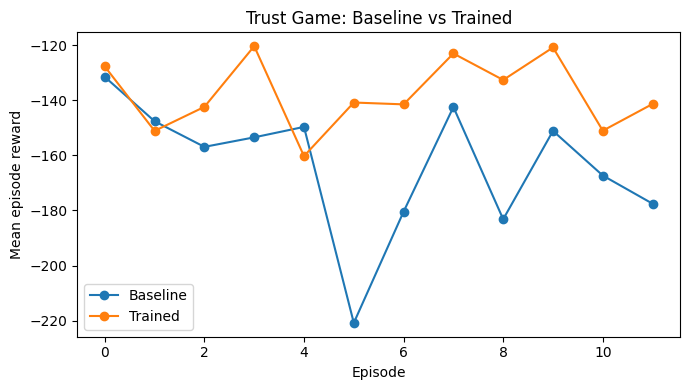

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(baseline_rewards, label='Baseline', marker='o')
plt.plot(trained_rewards, label='Trained', marker='o')
plt.xlabel('Episode')
plt.ylabel('Mean episode reward')
plt.title('Trust Game: Baseline vs Trained')
plt.legend()
plt.tight_layout()

import os
os.makedirs('eval_results', exist_ok=True)
plot_path = 'eval_results/training_reward_comparison.png'
plt.savefig(plot_path, dpi=180)
print('Saved plot to', plot_path)

In [ ]:
trainer.save_model('outputs/trust-game-sft/final')
tokenizer.save_pretrained('outputs/trust-game-sft/final')
print('Saved model to outputs/trust-game-sft/final')

Unsloth: Restored added_tokens_decoder metadata in outputs/trust-game-sft/final/tokenizer_config.json.


Saved model to outputs/trust-game-sft/final
